In [1]:
import re
import pickle
import numpy as np
import mne
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr
import os

In [2]:
def load_pickle_data(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


coh_base_dir = '../data/COH/'
pli_base_dir = '../data/PLI/'
ste_base_dir = '../data/STE/'


BD_coh = load_pickle_data(coh_base_dir + 'BD_coh_data.pkl')
MDD_coh = load_pickle_data(coh_base_dir + 'MDD_coh_data.pkl')
BD_pli = load_pickle_data(pli_base_dir + 'BD_pli_data.pkl')
MDD_pli = load_pickle_data(pli_base_dir + 'MDD_pli_data.pkl')
BD_ste = load_pickle_data(ste_base_dir + 'BD_ste_data.pkl')
MDD_ste = load_pickle_data(ste_base_dir + 'MDD_ste_data.pkl')


montage = mne.channels.read_custom_montage("../電極通道/BD_MDD_HC_29_test.loc")
ch_names = montage.ch_names
n_chan = len(ch_names)

frequency_bands = ['delta', 'theta', 'alpha', 'betalow', 'betahigh', 'gamma']

In [9]:
r_idx, c_idx = np.triu_indices(n_chan, k=1)
n_chan_pairs = len(r_idx)
ste_mask = ~np.eye(n_chan, dtype=bool)
n_ste_pairs = ste_mask.sum()


df_raw = pd.read_csv('../subject_finalized.csv')


def normalize_id(s):
    return re.sub(r'\(.*?\)', '', s).upper().strip()

df_raw['norm_id'] = df_raw['subjectID'].astype(str).apply(normalize_id)
df_scores = df_raw.set_index('norm_id')


BD_subjects = sorted(BD_coh.keys())
MDD_subjects = sorted(MDD_coh.keys())


BD_norm = [normalize_id(s) for s in BD_subjects]
BD_norm = [s for s in BD_norm if s in df_scores.index]
MDD_norm = [normalize_id(s) for s in MDD_subjects]
MDD_norm = [s for s in MDD_norm if s in df_scores.index]


score_arrays = {
    'BD': {
        'HAMD': df_scores.loc[BD_norm, 'HAMD'].values,
        'YMRS': df_scores.loc[BD_norm, 'YMRS'].values
    },
    'MDD': {
        'BDI2': df_scores.loc[MDD_norm, 'BDI2'].values
    }
}

In [4]:
def decode_coh(b, pi):
    return f"COH | {frequency_bands[b]} | {ch_names[r_idx[pi]]}-{ch_names[c_idx[pi]]}"

def decode_pli(b, pi):
    return f"PLI | {frequency_bands[b]} | {ch_names[r_idx[pi]]}-{ch_names[c_idx[pi]]}"

ste_pairs = [(i, j) for i in range(n_chan) for j in range(n_chan) if i != j]
def decode_ste(b, pi):
    i, j = ste_pairs[pi]
    return f"STE | {frequency_bands[b]} | {ch_names[i]}→{ch_names[j]}"


corr_data = {
    'BD': {'COH':{'HAMD': [], 'YMRS': []},
           'PLI':{'HAMD': [], 'YMRS': []},
           'STE':{'HAMD': [], 'YMRS': []},
           'ALL':{'HAMD': [], 'YMRS': []}},
    'MDD':{'COH':{'BDI2': []},
           'PLI':{'BDI2': []},
           'STE':{'BDI2': []},
           'ALL':{'BDI2': []}}
}

In [5]:
# BD: COH / PLI / STE
for b, band in enumerate(frequency_bands):
    # COH
    for pi in range(n_chan_pairs):
        desc = decode_coh(b, pi)

        vals = np.array([BD_coh[s_orig][band][pi] 
                         for s_orig in BD_subjects 
                         if normalize_id(s_orig) in BD_norm])
        r_h, _ = pearsonr(vals, score_arrays['BD']['HAMD'])
        r_y, _ = pearsonr(vals, score_arrays['BD']['YMRS'])
        for score in ['HAMD','YMRS']:
            corr_data['BD']['COH'][score].append({'desc':desc, 'vals':vals, 'r':r_h if score=='HAMD' else r_y})
            corr_data['BD']['ALL'][score].append({'desc':desc, 'vals':vals, 'r':r_h if score=='HAMD' else r_y})
    # PLI
    for pi in range(n_chan_pairs):
        desc = decode_pli(b, pi)
        vals = np.array([BD_pli[s_orig][band][pi] 
                         for s_orig in BD_subjects 
                         if normalize_id(s_orig) in BD_norm])
        r_h, _ = pearsonr(vals, score_arrays['BD']['HAMD'])
        r_y, _ = pearsonr(vals, score_arrays['BD']['YMRS'])
        for score in ['HAMD','YMRS']:
            corr_data['BD']['PLI'][score].append({'desc':desc, 'vals':vals, 'r':r_h if score=='HAMD' else r_y})
            corr_data['BD']['ALL'][score].append({'desc':desc, 'vals':vals, 'r':r_h if score=='HAMD' else r_y})
    # STE
    for pi in range(n_ste_pairs):
        desc = decode_ste(b, pi)
        vals = np.array([BD_ste[s_orig][band][ste_mask][pi] 
                         for s_orig in BD_subjects 
                         if normalize_id(s_orig) in BD_norm])
        r_h, _ = pearsonr(vals, score_arrays['BD']['HAMD'])
        r_y, _ = pearsonr(vals, score_arrays['BD']['YMRS'])
        for score in ['HAMD','YMRS']:
            corr_data['BD']['STE'][score].append({'desc':desc, 'vals':vals, 'r':r_h if score=='HAMD' else r_y})
            corr_data['BD']['ALL'][score].append({'desc':desc, 'vals':vals, 'r':r_h if score=='HAMD' else r_y})

In [6]:
# MDD: COH / PLI / STE
for b, band in enumerate(frequency_bands):
    # COH
    for pi in range(n_chan_pairs):
        desc = decode_coh(b, pi)
        vals = np.array([MDD_coh[s_orig][band][pi] 
                         for s_orig in MDD_subjects 
                         if normalize_id(s_orig) in MDD_norm])
        r_b, _ = pearsonr(vals, score_arrays['MDD']['BDI2'])
        corr_data['MDD']['COH']['BDI2'].append({'desc':desc, 'vals':vals, 'r':r_b})
        corr_data['MDD']['ALL']['BDI2'].append({'desc':desc, 'vals':vals, 'r':r_b})
    # PLI
    for pi in range(n_chan_pairs):
        desc = decode_pli(b, pi)
        vals = np.array([MDD_pli[s_orig][band][pi] 
                         for s_orig in MDD_subjects 
                         if normalize_id(s_orig) in MDD_norm])
        r_b, _ = pearsonr(vals, score_arrays['MDD']['BDI2'])
        corr_data['MDD']['PLI']['BDI2'].append({'desc':desc, 'vals':vals, 'r':r_b})
        corr_data['MDD']['ALL']['BDI2'].append({'desc':desc, 'vals':vals, 'r':r_b})
    # STE
    for pi in range(n_ste_pairs):
        desc = decode_ste(b, pi)
        vals = np.array([MDD_ste[s_orig][band][ste_mask][pi] 
                         for s_orig in MDD_subjects 
                         if normalize_id(s_orig) in MDD_norm])
        r_b, _ = pearsonr(vals, score_arrays['MDD']['BDI2'])
        corr_data['MDD']['STE']['BDI2'].append({'desc':desc, 'vals':vals, 'r':r_b})
        corr_data['MDD']['ALL']['BDI2'].append({'desc':desc, 'vals':vals, 'r':r_b})

Saved figure to: ../result_FA/correlation/BD_COH_vs_HAMD.png


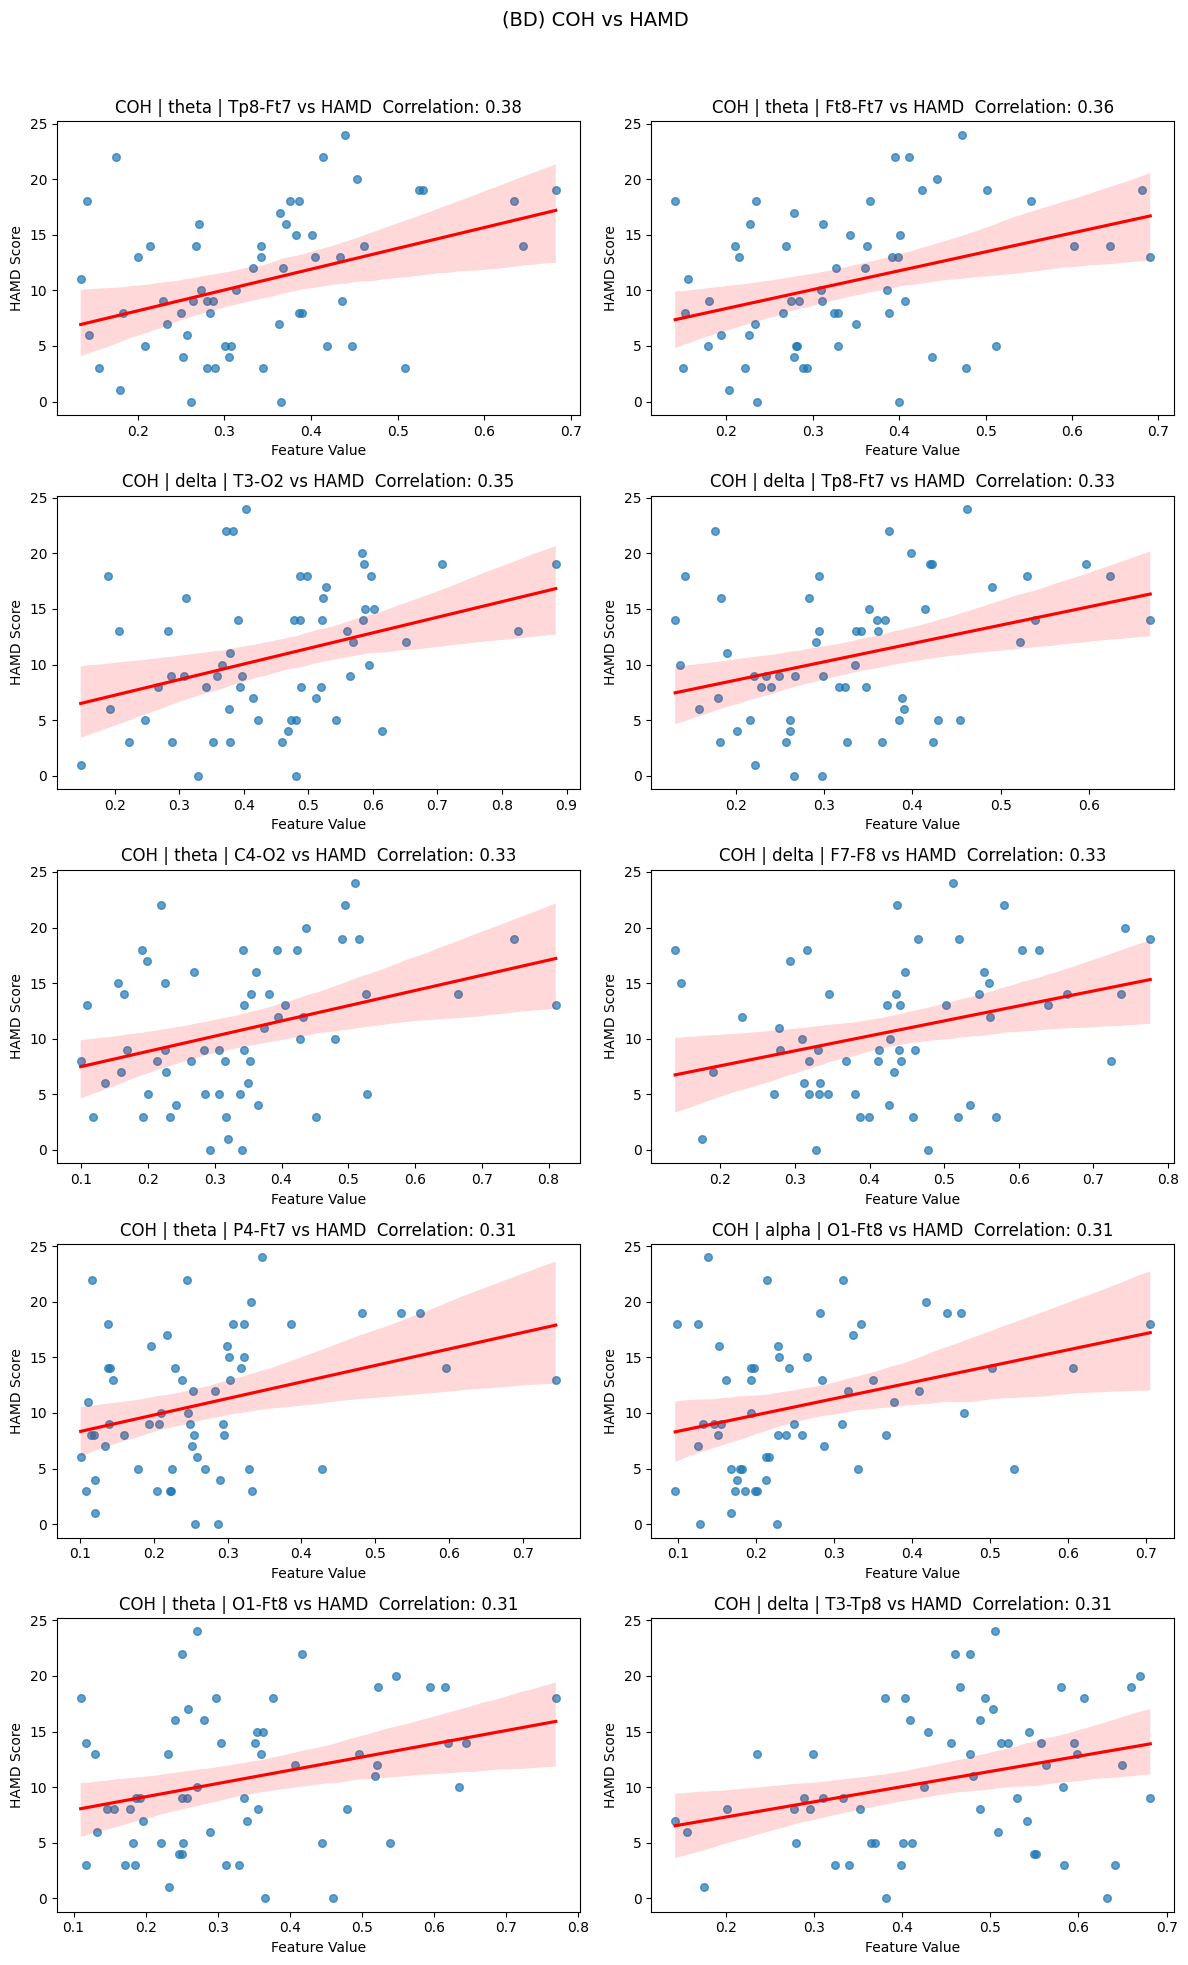

Saved figure to: ../result_FA/correlation/BD_COH_vs_YMRS.png


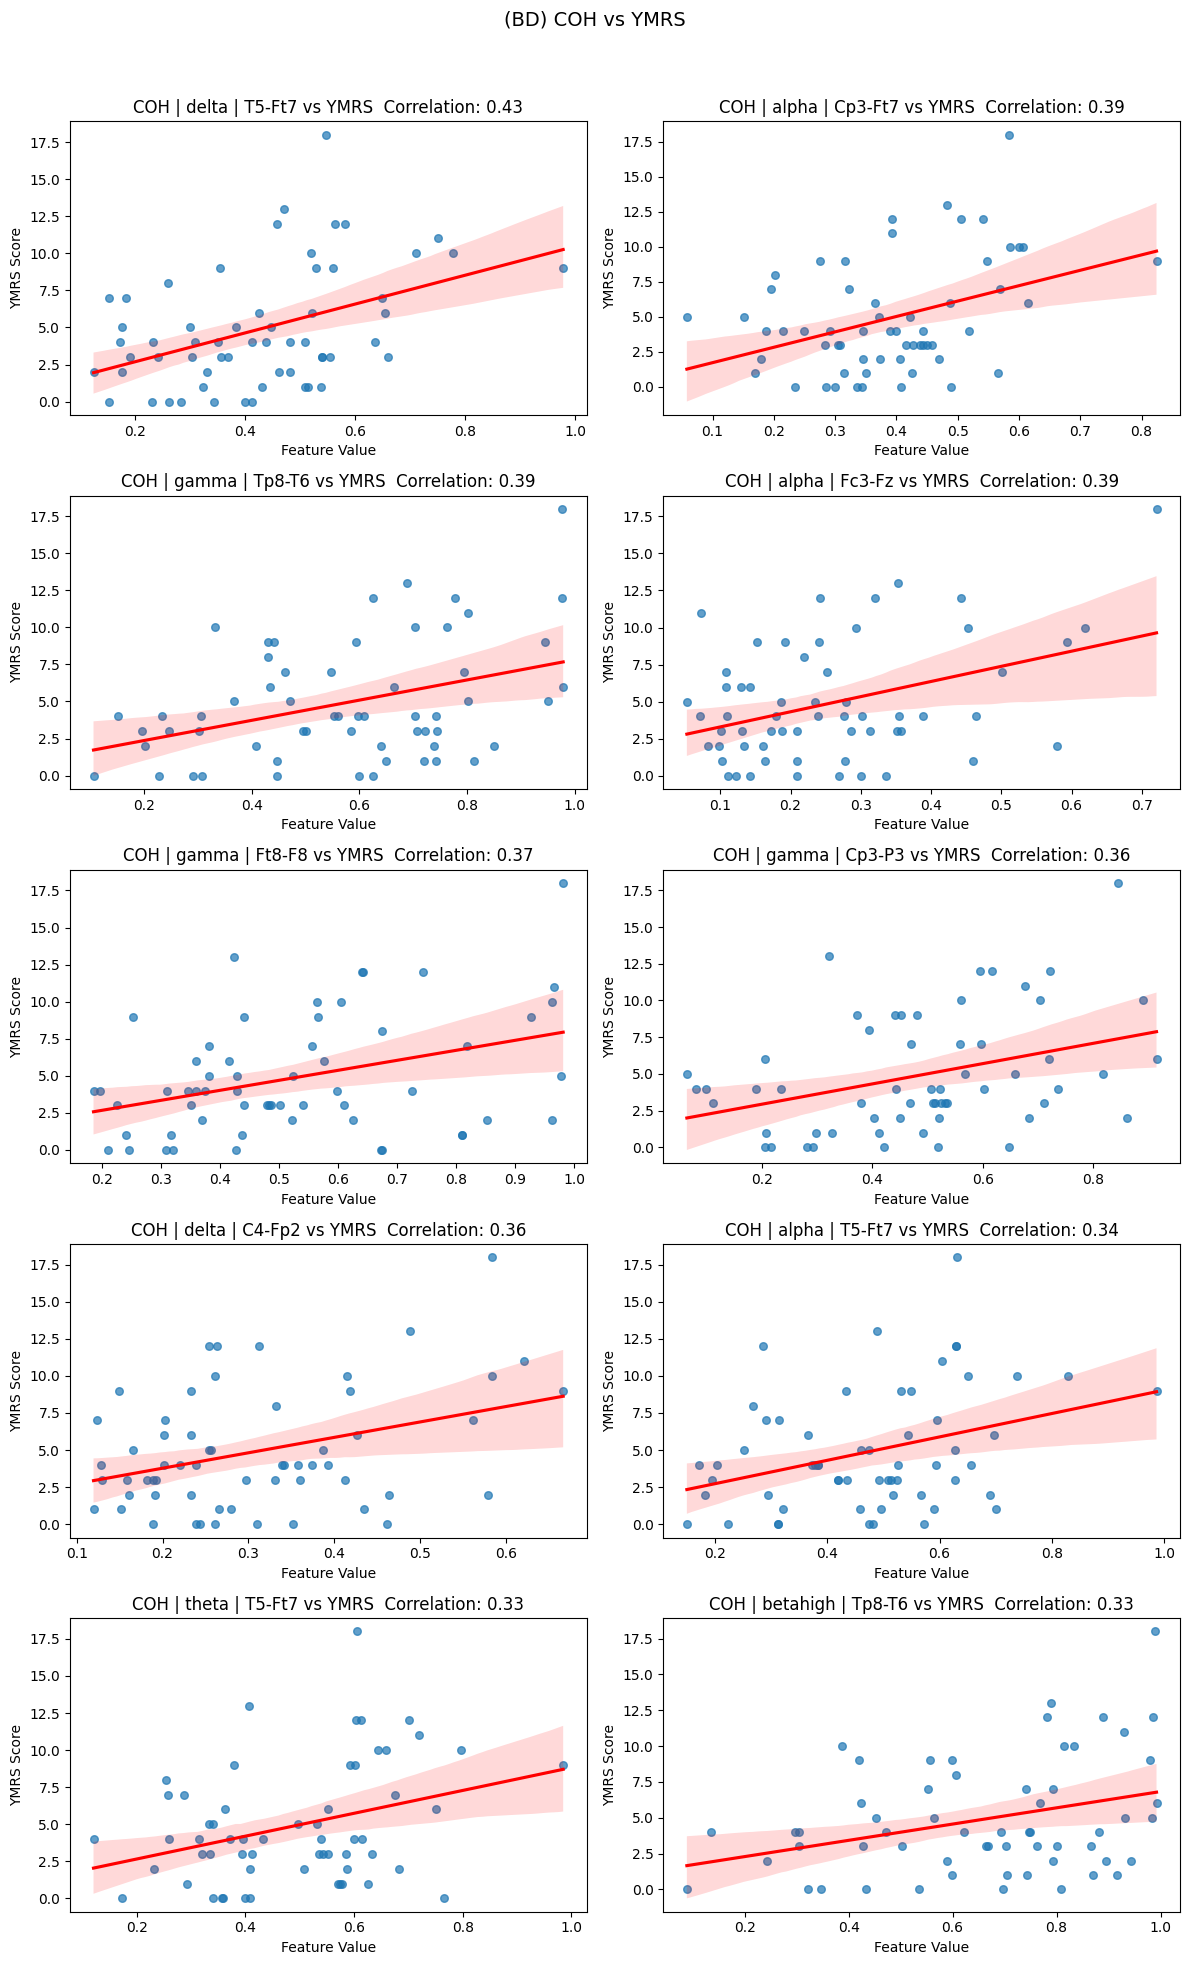

Saved figure to: ../result_FA/correlation/BD_PLI_vs_HAMD.png


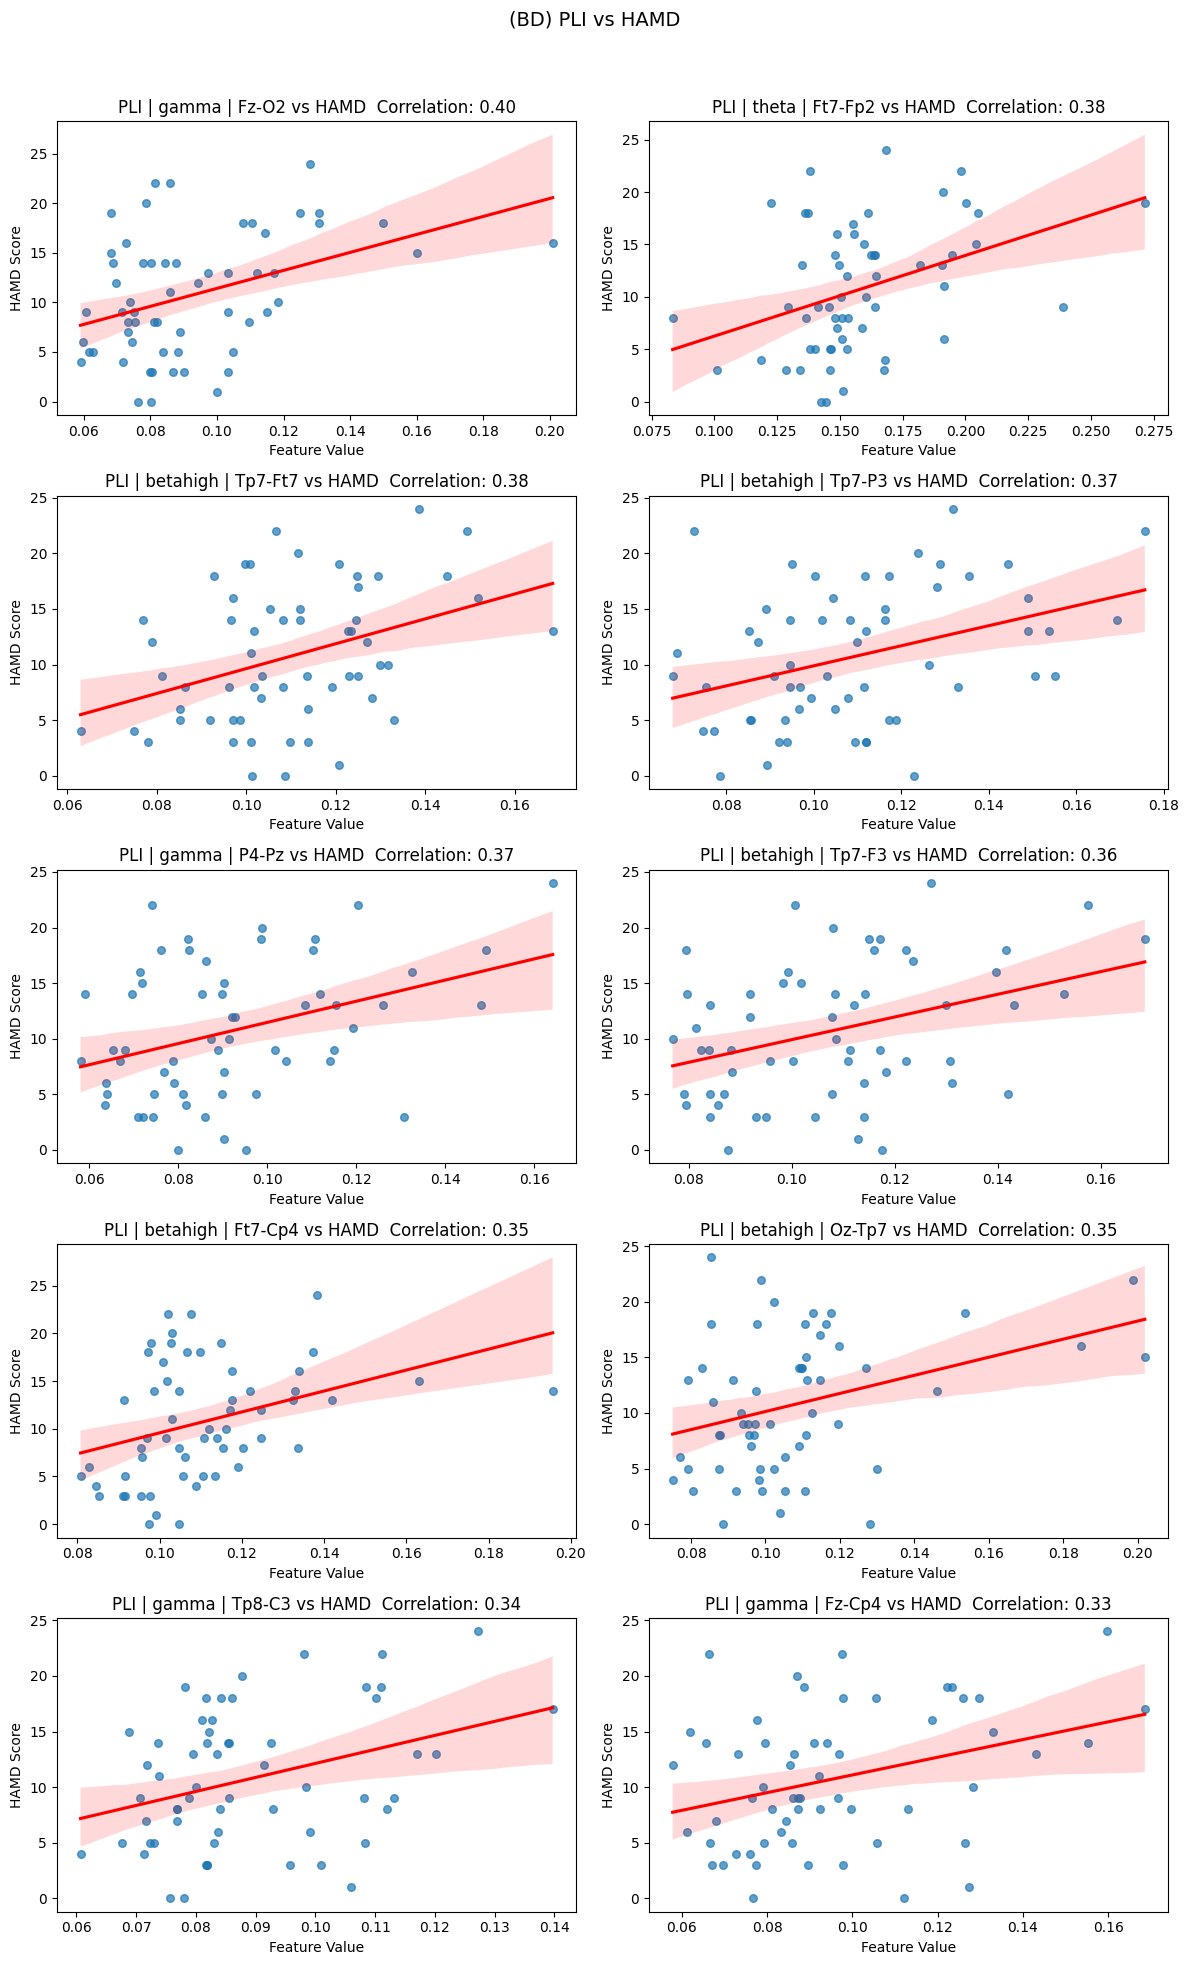

Saved figure to: ../result_FA/correlation/BD_PLI_vs_YMRS.png


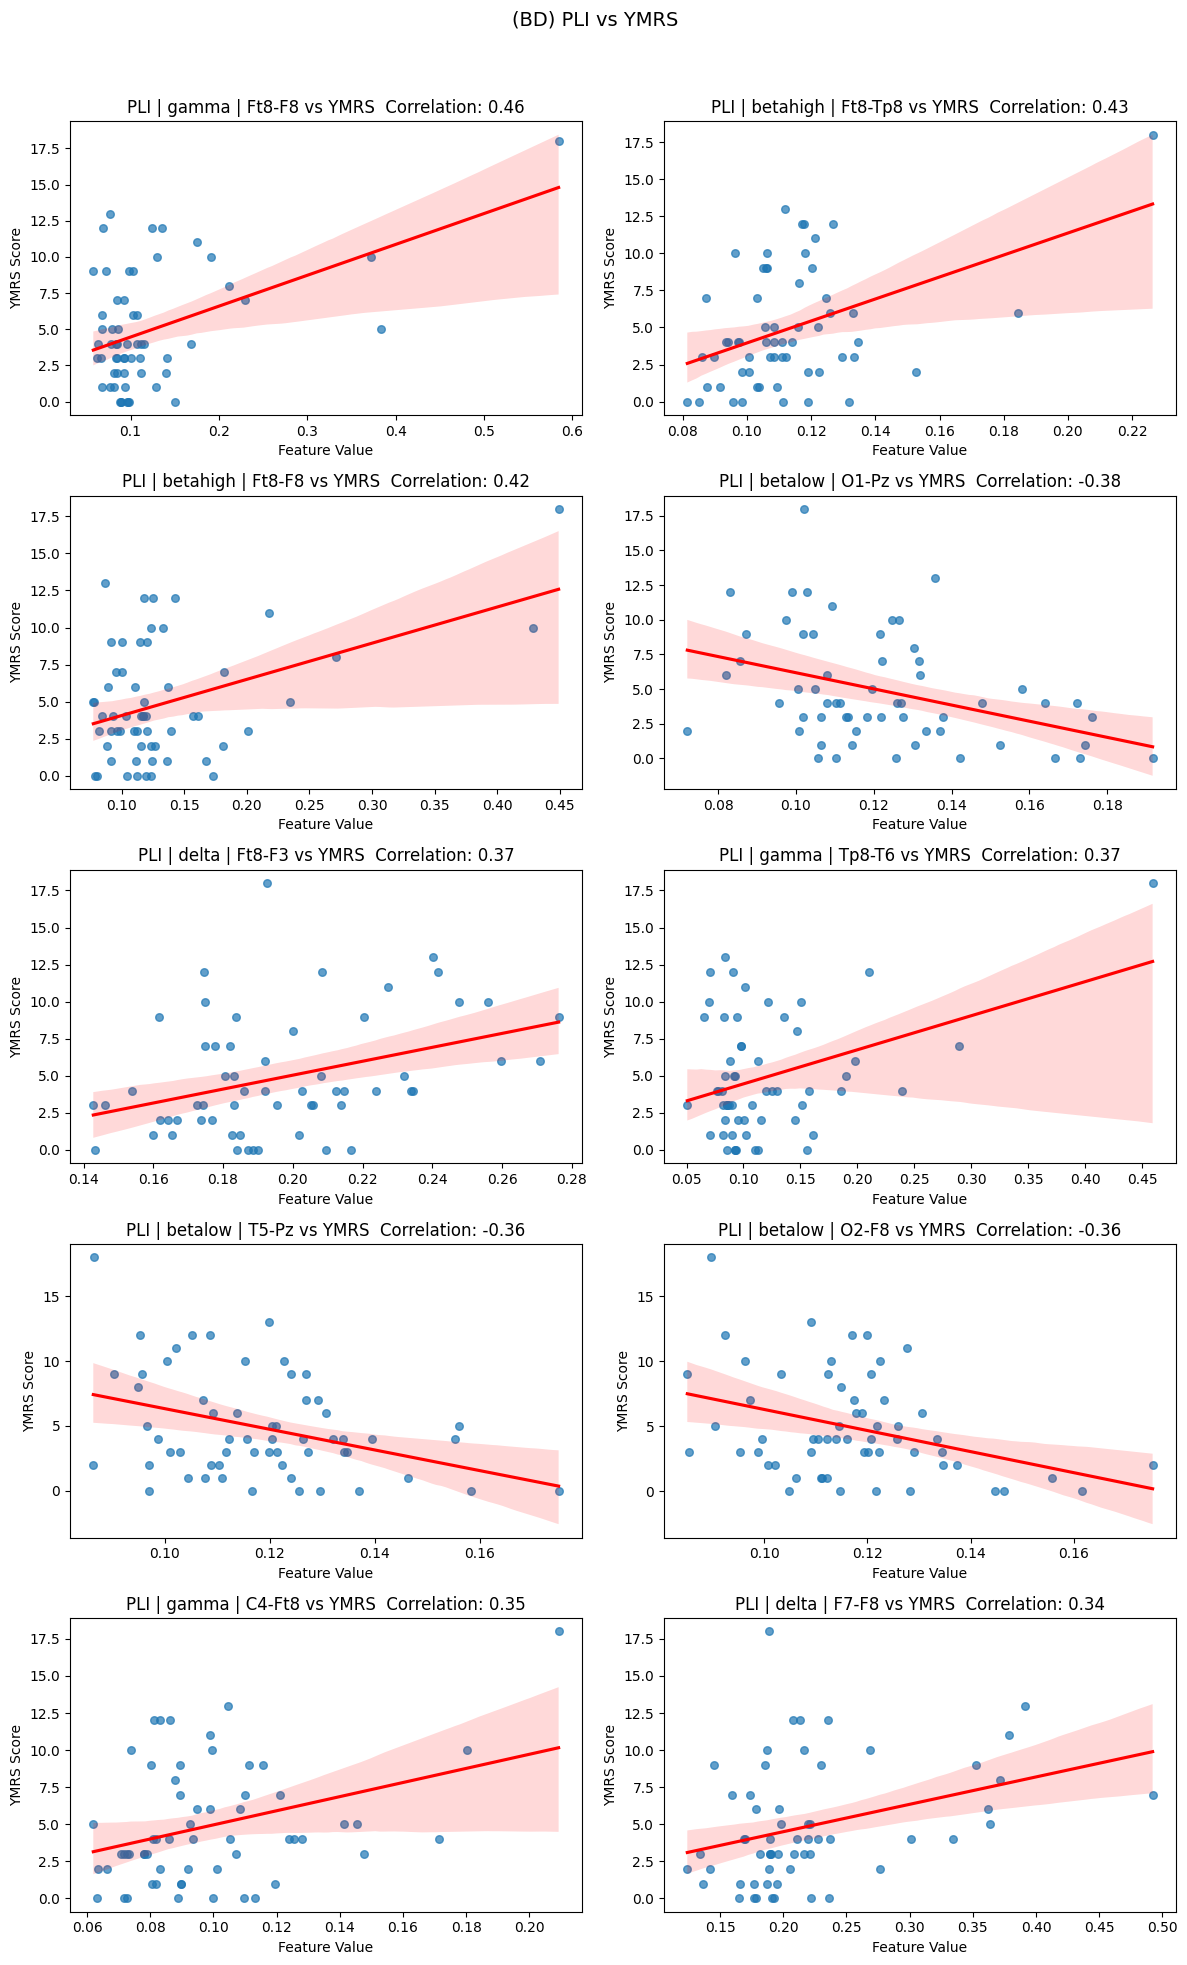

Saved figure to: ../result_FA/correlation/BD_STE_vs_HAMD.png


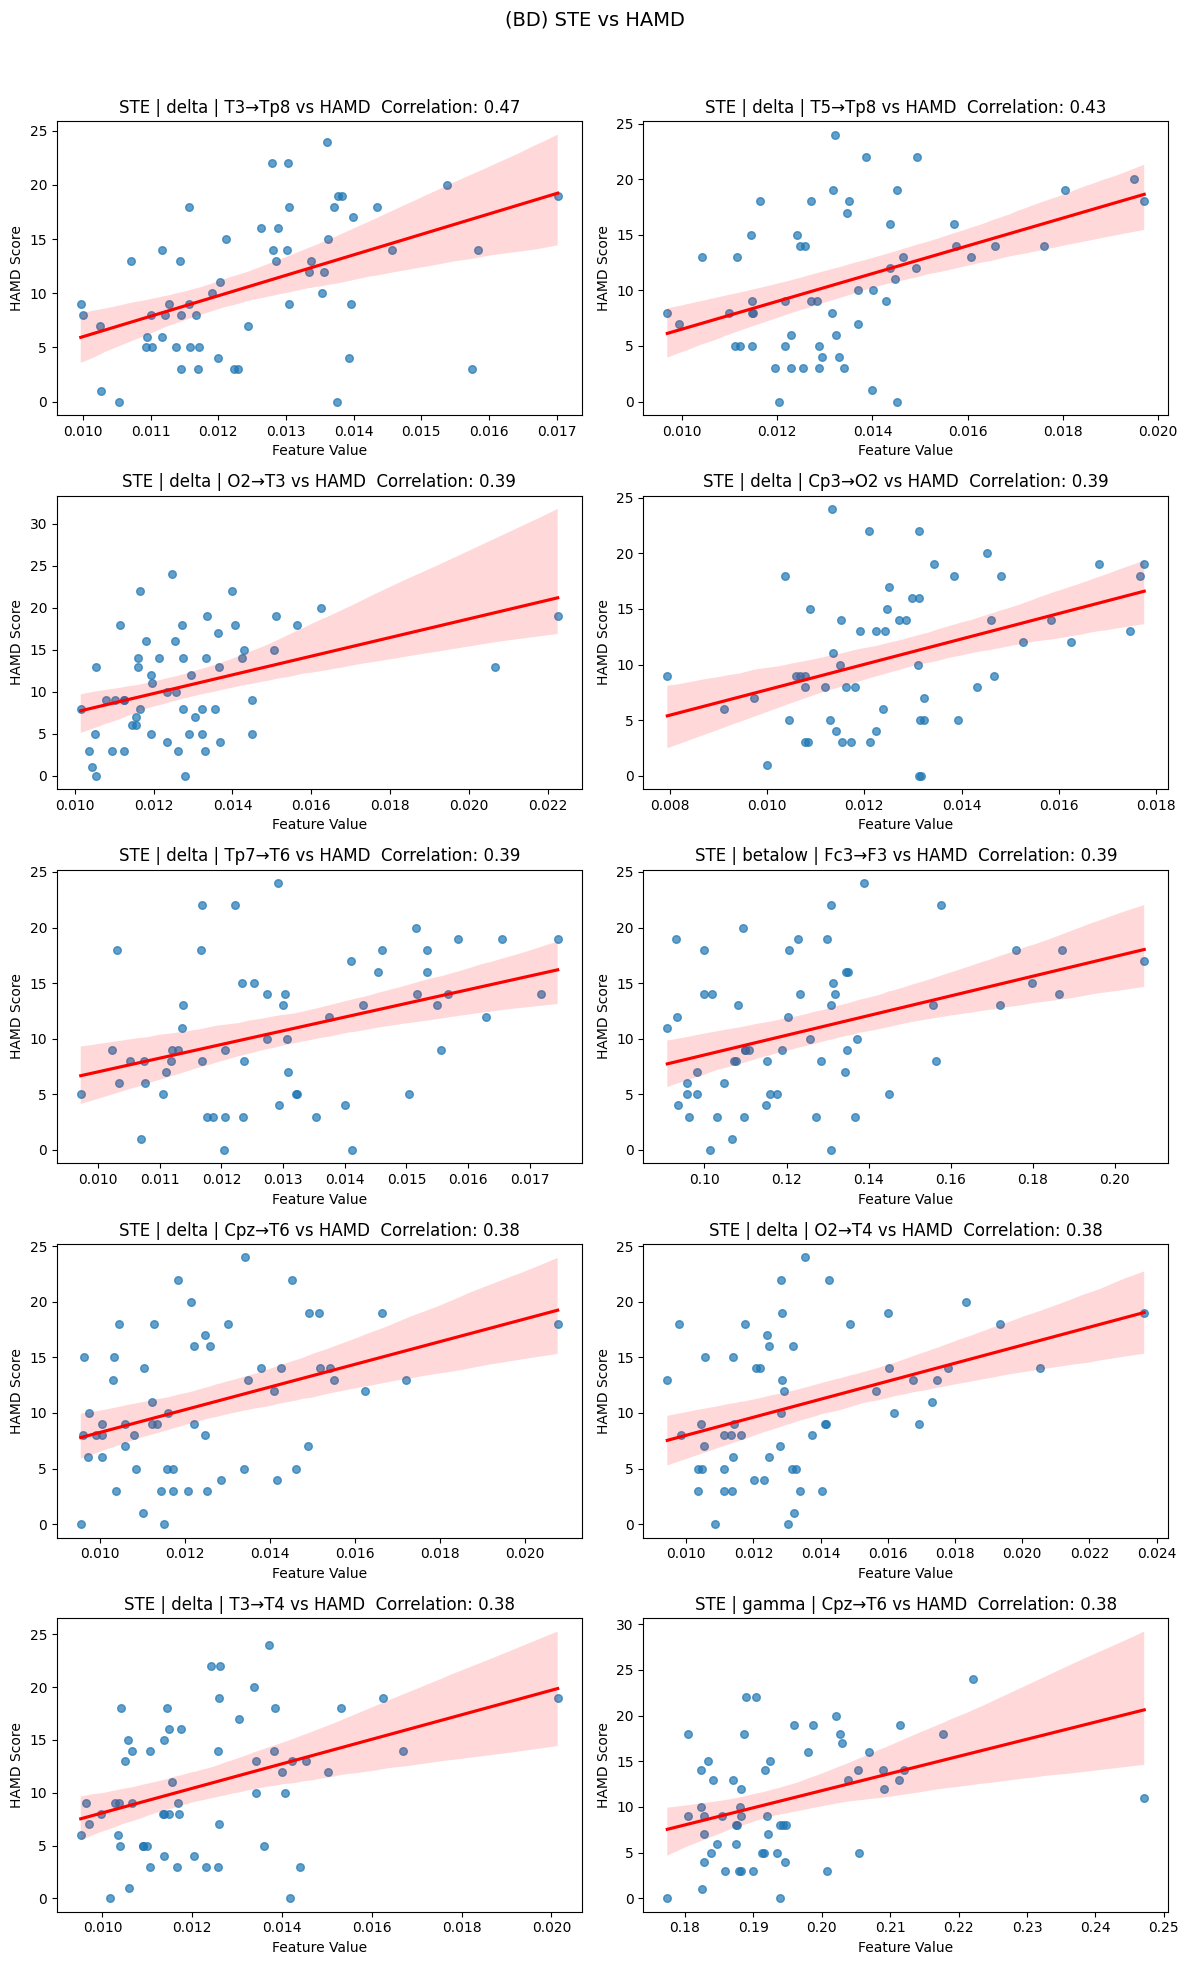

Saved figure to: ../result_FA/correlation/BD_STE_vs_YMRS.png


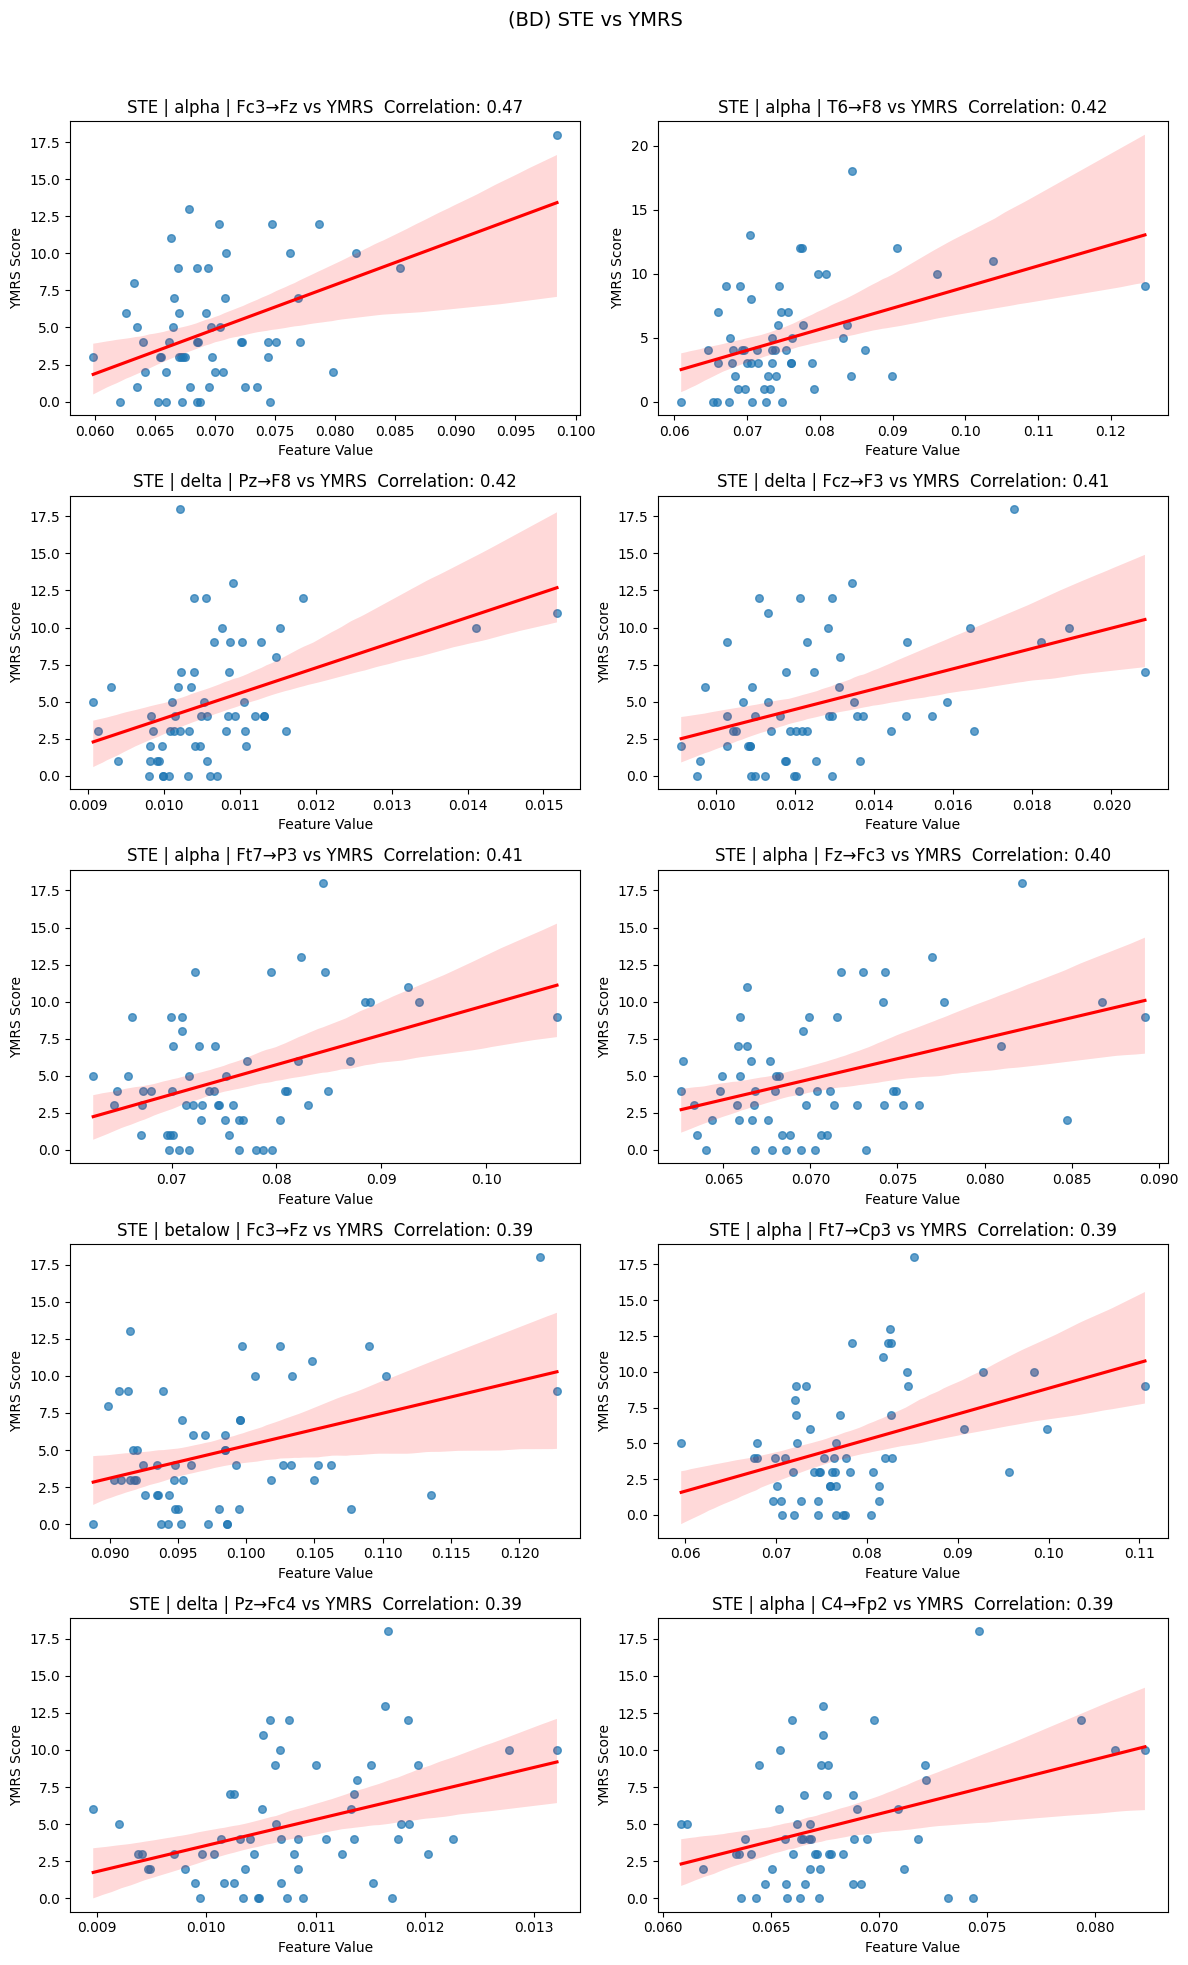

Saved figure to: ../result_FA/correlation/BD_ALL_vs_HAMD.png


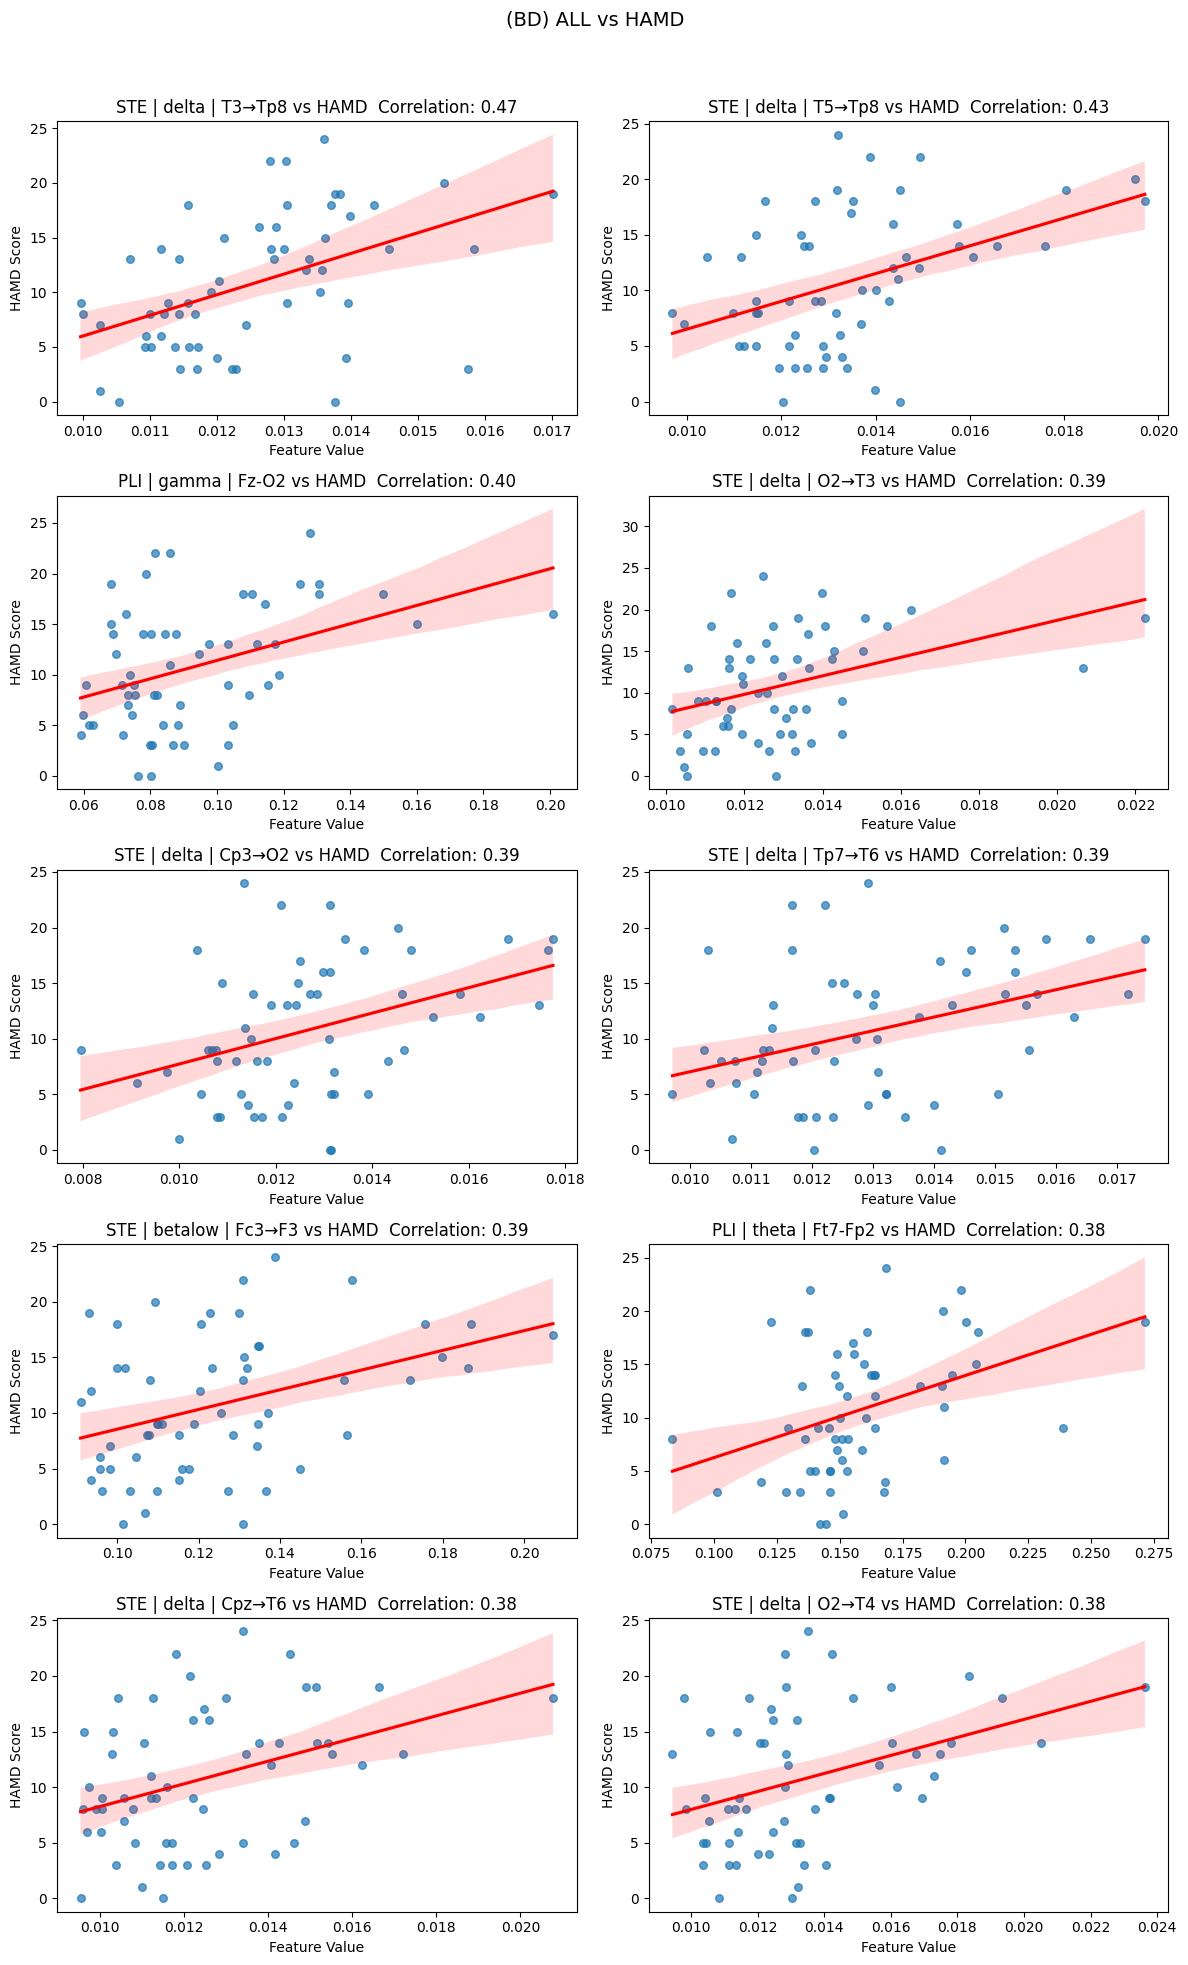

Saved figure to: ../result_FA/correlation/BD_ALL_vs_YMRS.png


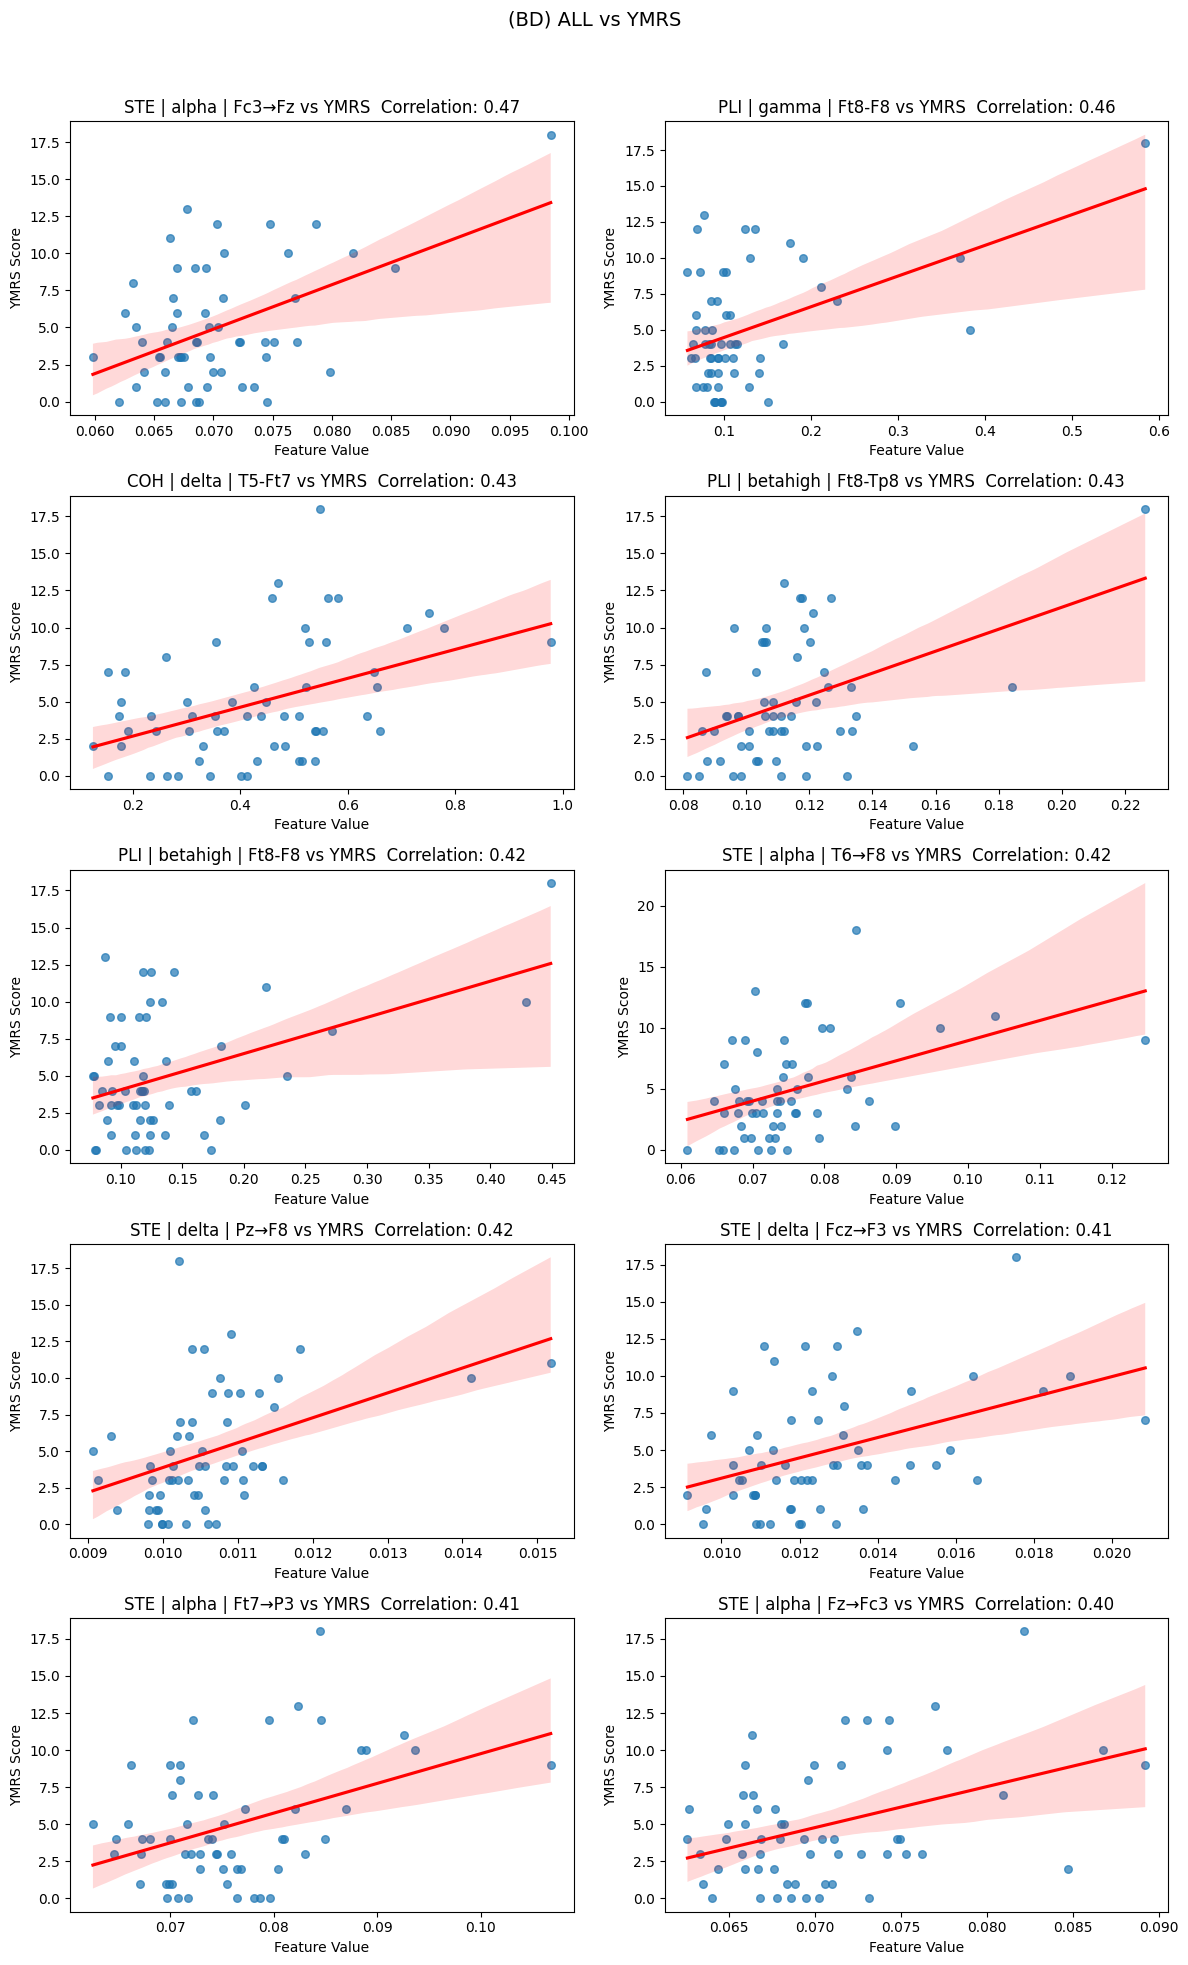

Saved figure to: ../result_FA/correlation/MDD_COH_vs_BDI2.png


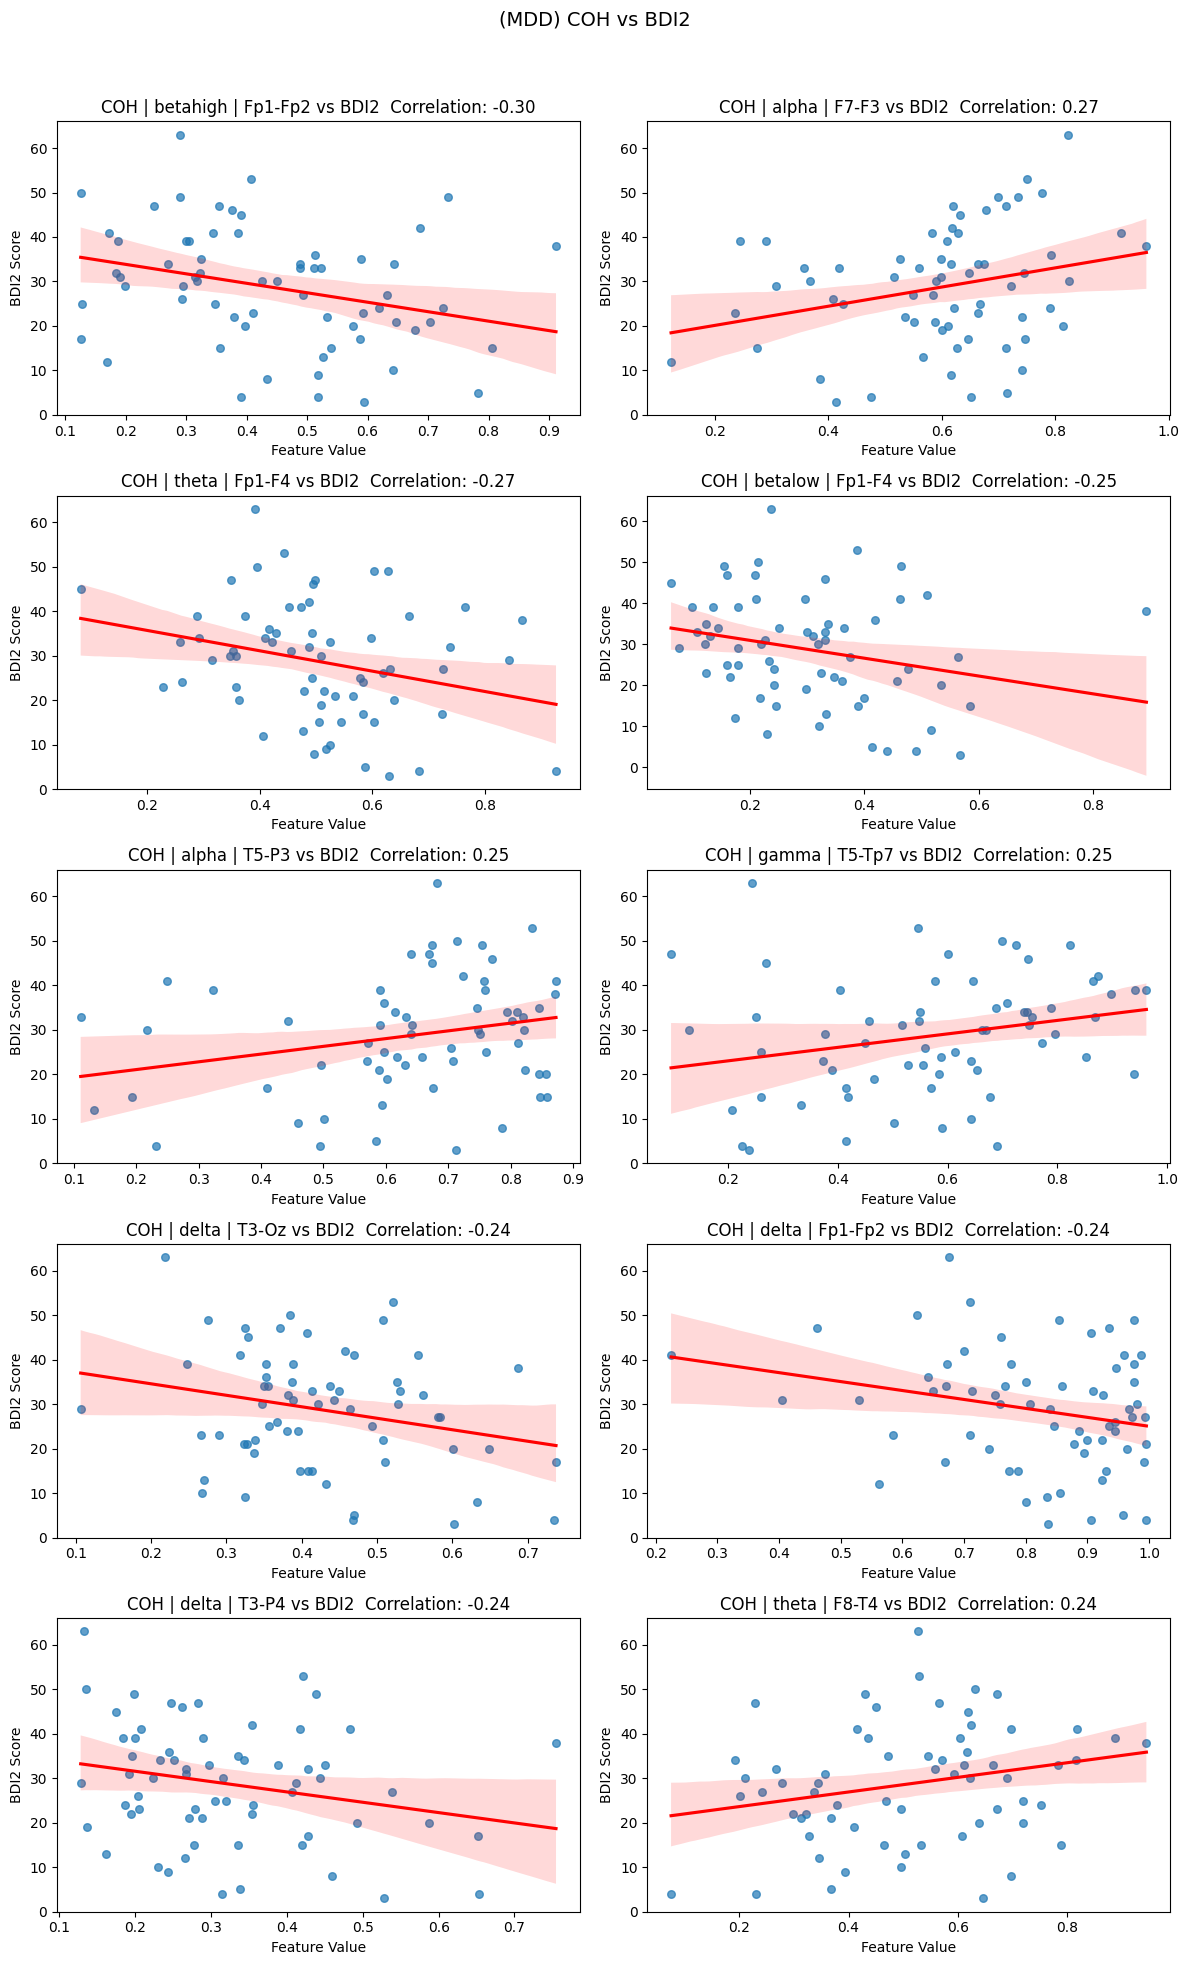

Saved figure to: ../result_FA/correlation/MDD_PLI_vs_BDI2.png


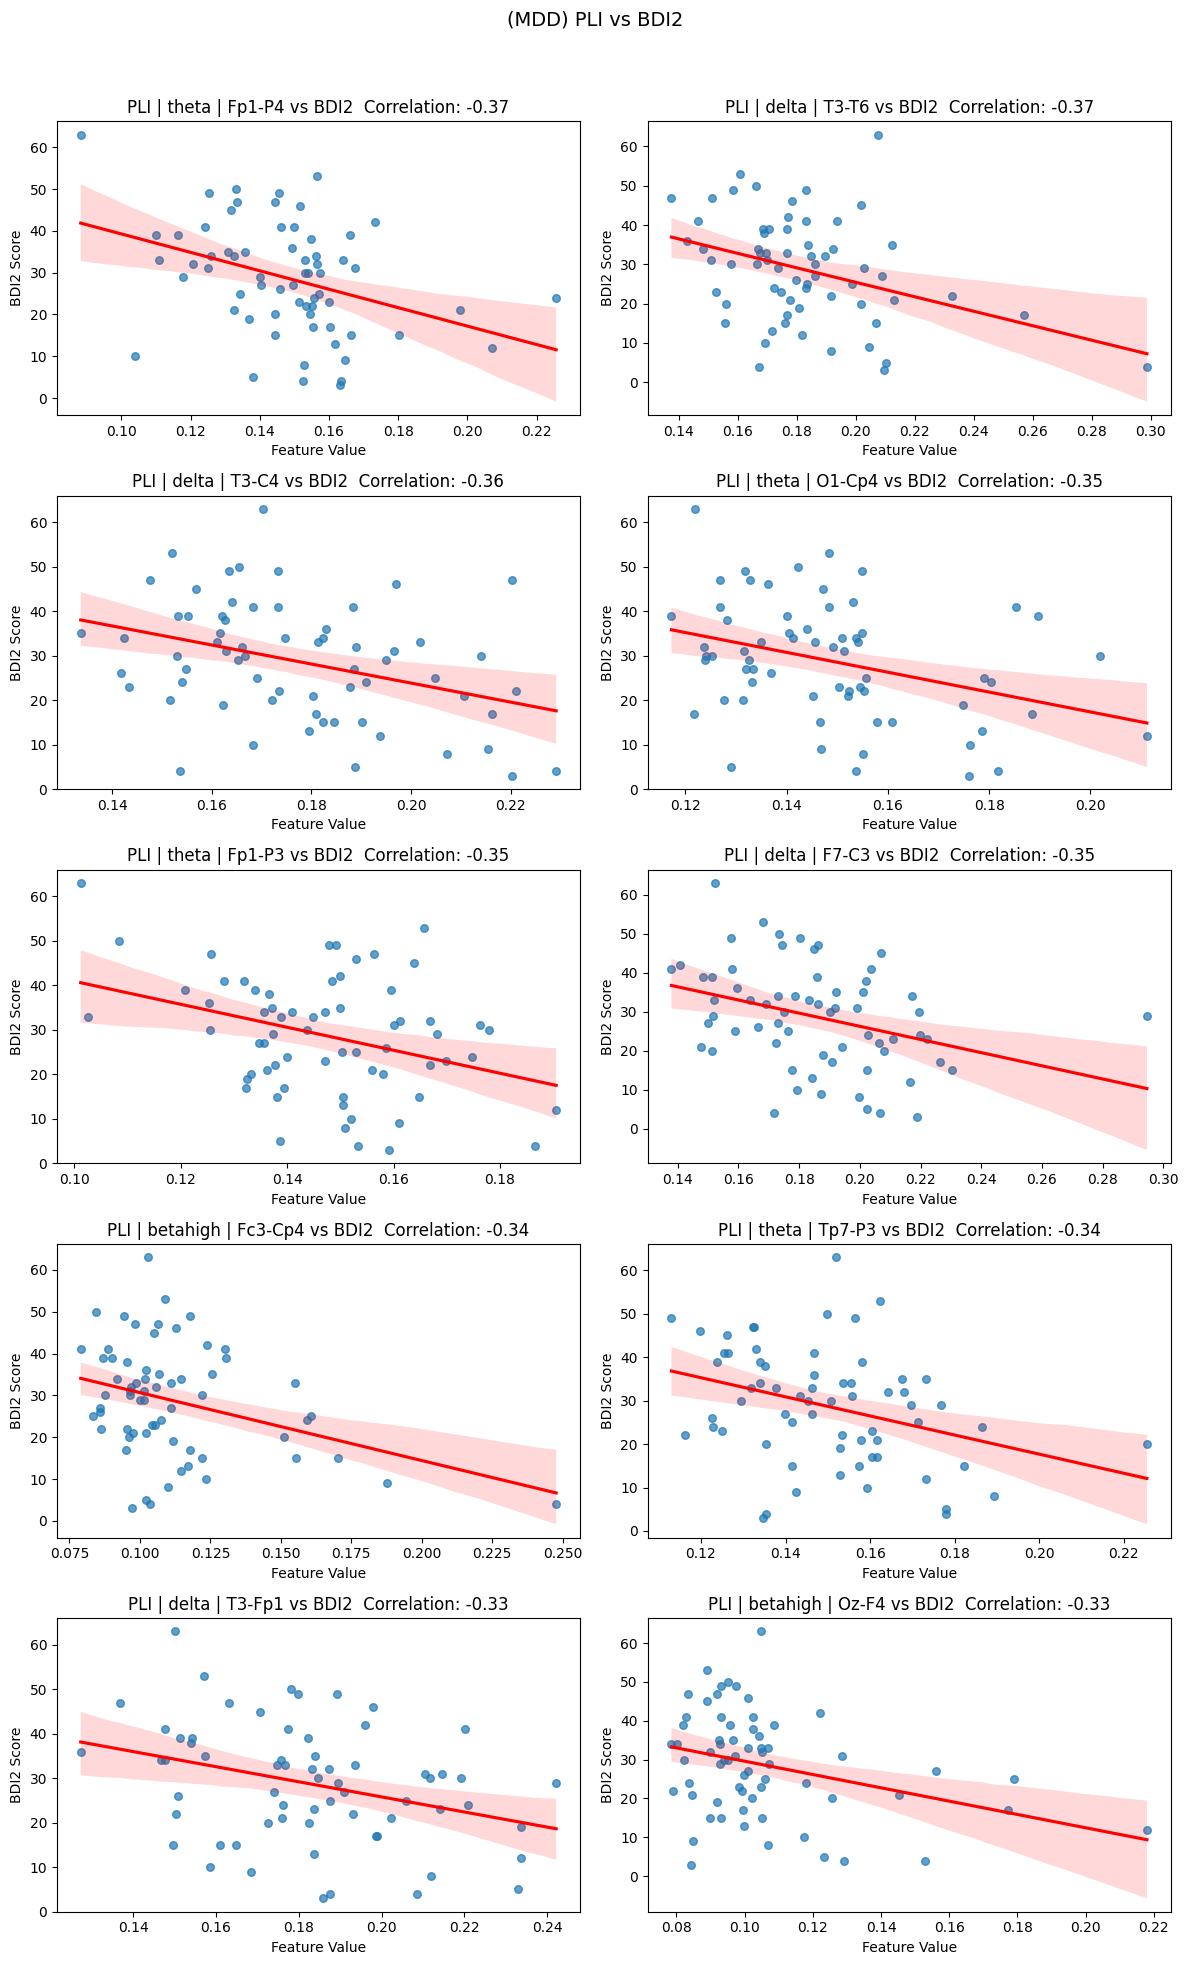

Saved figure to: ../result_FA/correlation/MDD_STE_vs_BDI2.png


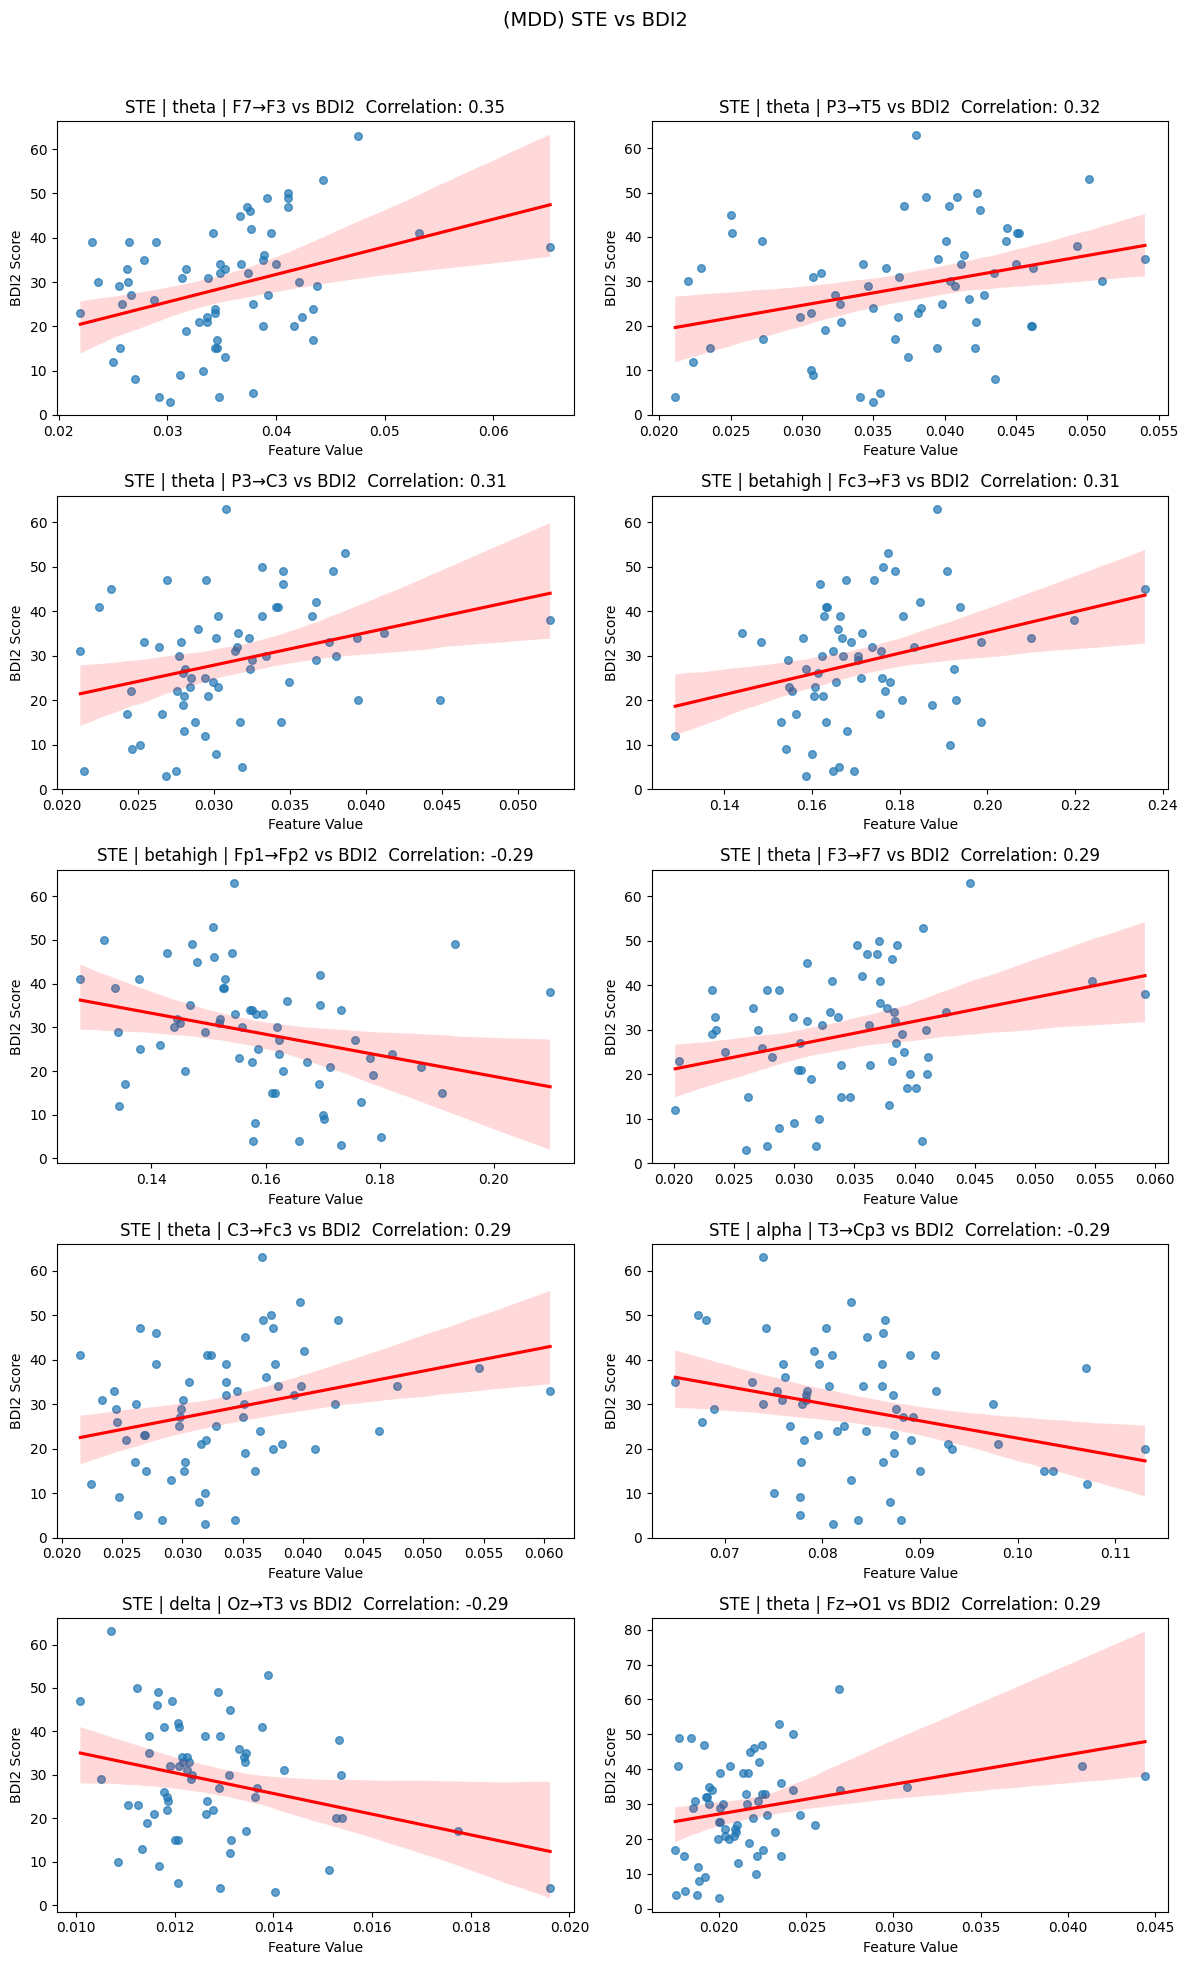

Saved figure to: ../result_FA/correlation/MDD_ALL_vs_BDI2.png


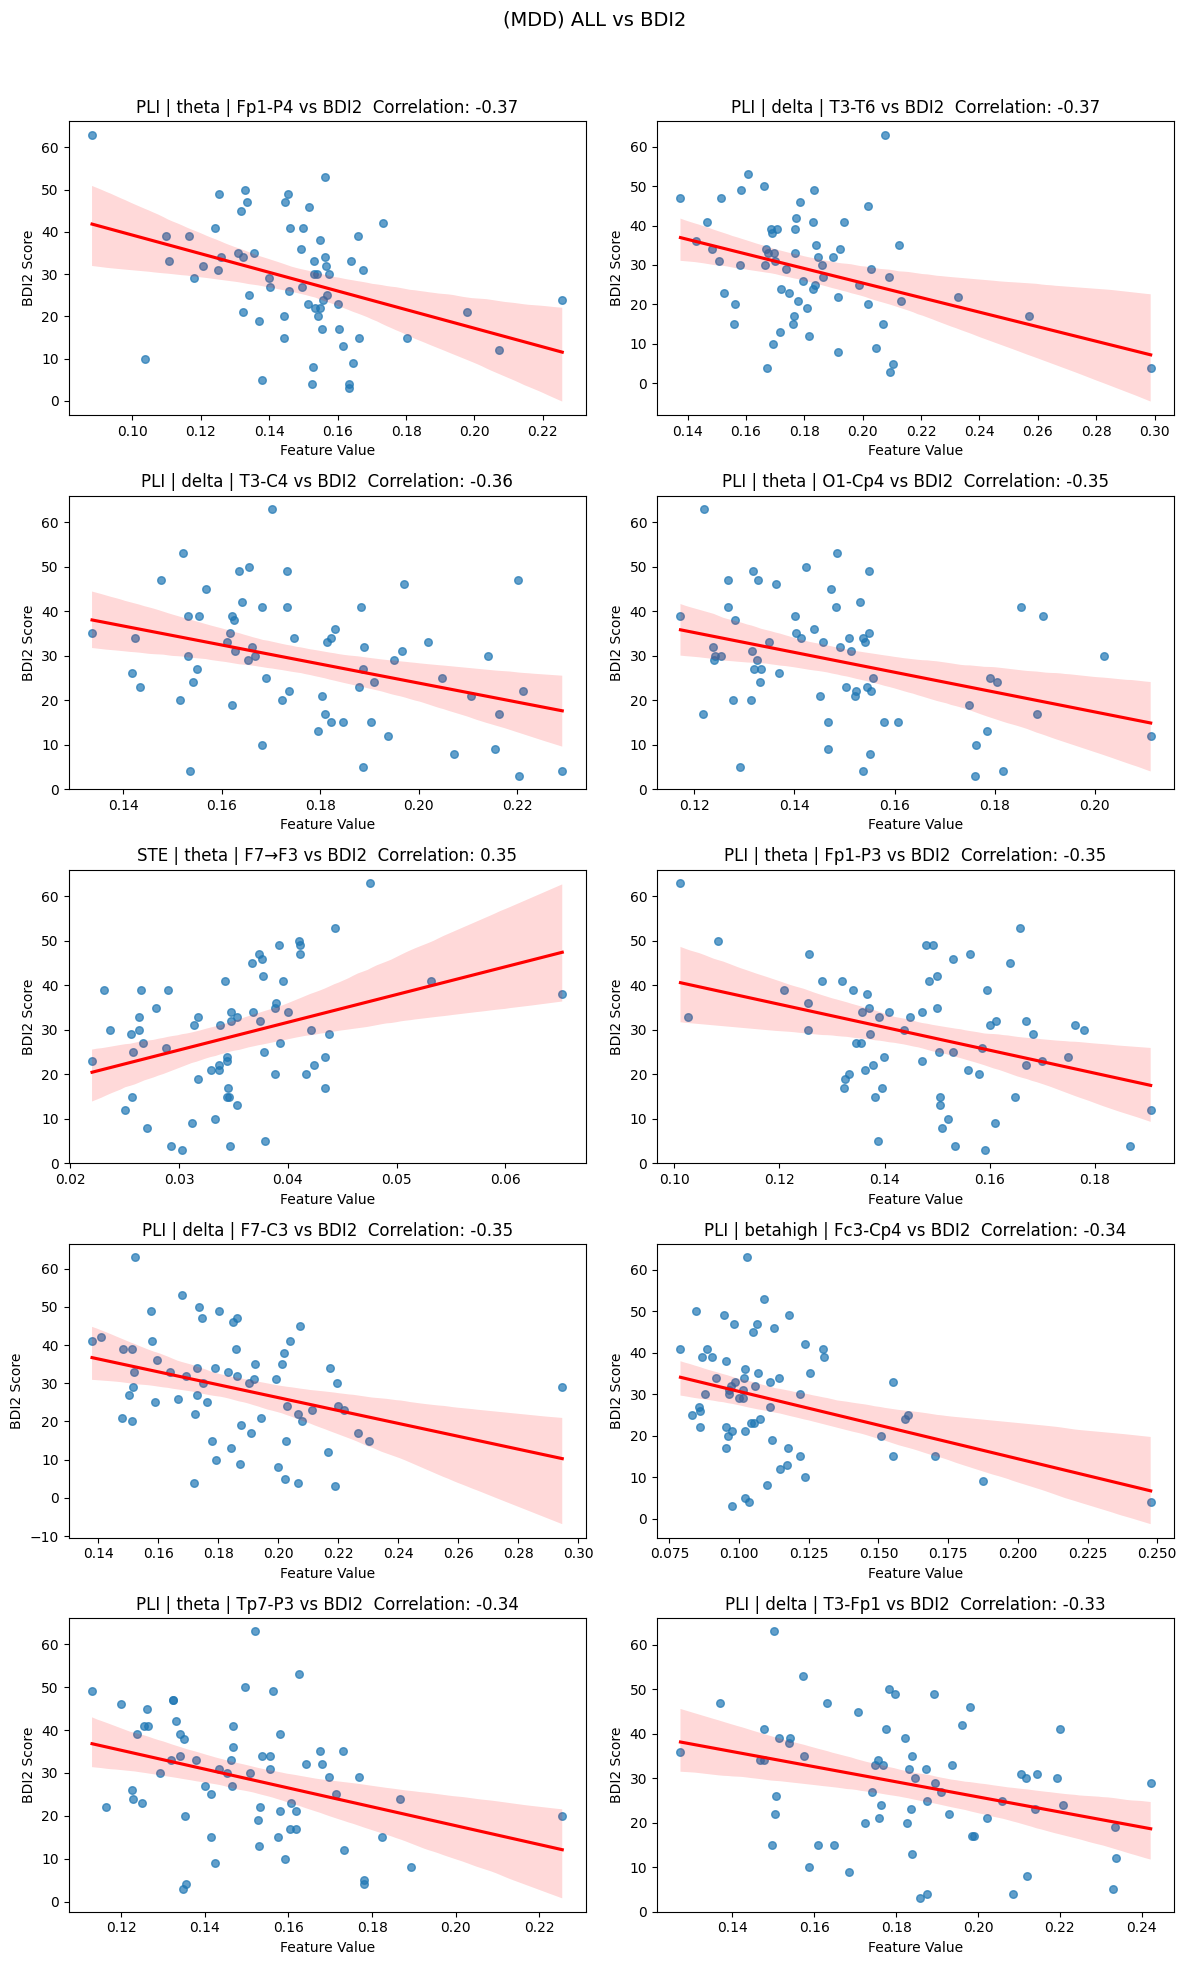

In [7]:
def plot_top10_scatter(items, scores, title, save_dir=None):
    top10 = sorted(items, key=lambda x: abs(x['r']), reverse=True)[:10]
    fig, axes = plt.subplots(5, 2, figsize=(12, 20), dpi=100)
    axes = axes.flatten()
    for ax, it in zip(axes, top10):
        sns.regplot(x=it['vals'], y=scores, ax=ax,
                    scatter_kws={'s': 30, 'alpha':0.7},
                    line_kws={'color':'red'}, ci=95)
        ax.set_title(f"{it['desc']} vs {title.split()[-1]}  Correlation: {it['r']:.2f}", fontsize=12)
        ax.set_xlabel("Feature Value")
        ax.set_ylabel(f"{title.split()[-1]} Score")
    for ax in axes[len(top10):]:
        ax.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        safe_title = title.replace(" ", "_").replace("(", "").replace(")", "")
        filepath = os.path.join(save_dir, f"{safe_title}.png")
        fig.savefig(filepath, dpi=100)
        print(f"Saved figure to: {filepath}")

    plt.show()
    plt.close(fig)


output_dir = "../result_FA/correlation/"  

for group in ['BD', 'MDD']:
    for modality in corr_data[group]:
        for score_name, items in corr_data[group][modality].items():

            title = f"({group}) {modality} vs {score_name}"
            scores = score_arrays[group][score_name]
            plot_top10_scatter(items, scores, title, save_dir=output_dir)
